## Équation de la chaleur 1D résolution par un PINN

In [1]:
import jax
import jax.numpy as jnp
import optax
import numpy as np
import matplotlib.pyplot as plt

In [2]:
print(jax.devices())

[CpuDevice(id=0)]


**Domaine et constantes Pyhsique**

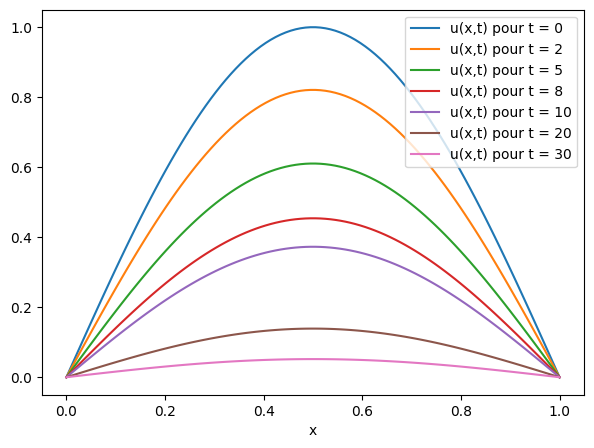

In [3]:
#Longueur de la barre (m)
L = 1
#Temps total de la simulation (s)
T = 30
#Coefficient de diffusion (m^2/s)
kappa = 1e-2
#Valeur propre
omega = jnp.pi/L
#Conditions aux limites de Dirichlet homogènes
#En x=0 u=0 pour tout t
CL0 = 0
#En x=L u=0 pour tout t
CLL = 0
#Condition initial
#u(x,0) = sin(omega*x)
#Exact solution
def u_exact(x,t):
    return jnp.exp(-kappa*omega**2*t)*jnp.sin(omega*x)
#Plot de la solution
time = [0,2,5,8,10,20,30]
x = jnp.linspace(0,L,100)
plt.figure(figsize=(7,5))
for t in time:
    plt.plot(x,u_exact(x,t),label=f"u(x,t) pour t = {t}")
    plt.legend(loc="upper right")
plt.xlabel("x")
plt.show()

**Initialisation des paramètres**

In [4]:
key = jax.random.key(0) #initialisation de la PRNG
#Taille de l'entré
n_input = 2
#Taille de la sortie
n_output = 1
#nombre de couches cachée
n_layers = [n_input,50,50,50,n_output]

def init_layers(key,n_layers):
    layers = []
    for i in range(len(n_layers)-1):
        key, subkey = jax.random.split(key)
        W = jax.random.normal(subkey,(n_layers[i],n_layers[i+1]))/jnp.sqrt(n_layers[i+1])
        key, subkey = jax.random.split(key)
        b = jax.random.normal(subkey,(1,n_layers[i+1]))/jnp.sqrt(n_layers[i+1])
        layers.append({"W" : W,"b" : b})
    return layers, key

key, subkey = jax.random.split(key)
layers, key = init_layers(subkey,n_layers)
#si besoin je peux ajouter kappa comme inconnu par exemple
params = {
    "layers" : layers
}

**Le Forward**

In [5]:
def forward(params,X):
    n = len(params["layers"])
    Z = jax.nn.tanh(X @ params["layers"][0]["W"] + params["layers"][0]["b"])
    for i in range(1,n):
        Z = jax.nn.tanh(Z @ params["layers"][i]["W"] + params["layers"][i]["b"])
    return Z

**La loss function**

In [6]:
def loss_fn(params, x, t, omega, kappa, N, weights=(1,1,1)):

    def u(x_val, t_val):
        return forward(params, jnp.array([x_val, t_val])).squeeze()
    
    def pde_residual(x_val, t_val):
        u_t = jax.grad(u, argnums=1)(x_val, t_val)
        u_xx = jax.grad(jax.grad(u))(x_val, t_val)
        return u_t - kappa * u_xx
    
    vmap_u = jax.vmap(u, in_axes=(0,0))
    vmap_pde_residual = jax.vmap(pde_residual, in_axes=(0,0))

    residuals = vmap_pde_residual(x, t)
    pde_loss = jnp.mean(residuals**2)

    zeros = jnp.zeros(N)
    xL = L*jnp.ones(N)
    bc_loss = jnp.mean((vmap_u(zeros, t) - CL0)**2) + jnp.mean((vmap_u(xL, t) - CLL)**2)
    ic_loss = jnp.mean((vmap_u(x,zeros)-jnp.sin(omega*x))**2)

    total_loss = weights[0]*pde_loss + weights[1]*bc_loss + weights[2]*ic_loss
    
    return total_loss

**Le training**

In [8]:
lr = 3e-4

optimizer = optax.adam(lr)

def train_step(params,opt_state,N,key):
    key, subkey1, subkey2 = jax.random.split(key, 3)
    x = jax.random.uniform(subkey1, (N,), minval=0, maxval=L)
    t = jax.random.uniform(subkey2, (N,), minval=0, maxval=T)
    loss, grads = jax.value_and_grad(loss_fn)(params, x, t, omega, kappa, N)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss, key

def train(params, Nmc, num_steps, eval_interval, key):
    opt_state = optimizer.init(params)
    best_val_loss = float('inf')
    best_params = params
    for step in range(num_steps):
        key, subkey = jax.random.split(key)
        params, opt_state, loss, key = train_step(params, opt_state, Nmc, subkey)
        if step % eval_interval == 0:
            def u(x_val, t_val):
                return forward(params, jnp.array([x_val, t_val])).squeeze()
            key, subkey1, subkey2 = jax.random.split(key, 3)
            x = jax.random.uniform(subkey1, (Nmc,), minval=0, maxval=L)
            t = jax.random.uniform(subkey2, (Nmc,), minval=0, maxval=T)
            vmap_u = jax.vmap(u, in_axes=(0,0))
            test_loss = jnp.mean((vmap_u(x,t) - u_exact(x,t))**2)
            print(f"step {step} | train loss {loss:.4f} | test loss {test_loss:.4f}")
    return params, key


**La phase d'entrainement**

In [10]:
num_steps = 2000
eval_interval = num_steps//10
Nmc = 1000

key, subkey = jax.random.split(key)
best_params, key = train(params, Nmc, num_steps, eval_interval, subkey)

step 0 | train loss 1.2119 | test loss 0.0511
step 200 | train loss 0.1217 | test loss 0.0700
step 400 | train loss 0.1081 | test loss 0.0587
step 600 | train loss 0.1011 | test loss 0.0650
step 800 | train loss 0.0716 | test loss 0.0445
step 1000 | train loss 0.0319 | test loss 0.0205
step 1200 | train loss 0.0111 | test loss 0.0031
step 1400 | train loss 0.0077 | test loss 0.0019
step 1600 | train loss 0.0066 | test loss 0.0015
step 1800 | train loss 0.0064 | test loss 0.0013


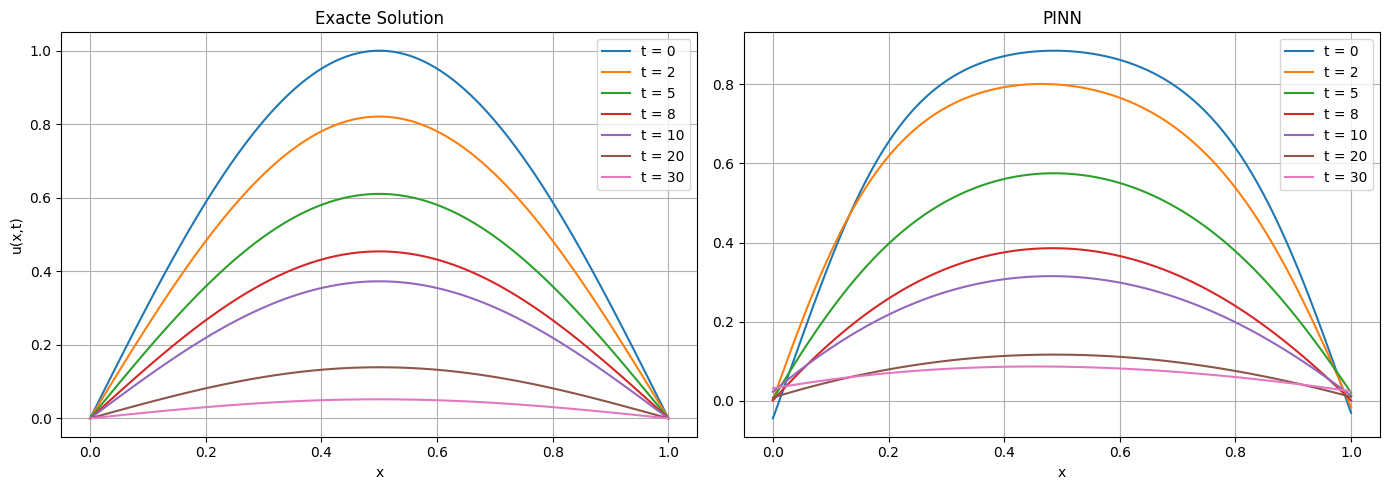

In [ ]:
#Plot de la solution et de l'approximation du PINN
def u_pinn(x, t):
    return forward(best_params, jnp.array([x, t])).squeeze()

time = [0,2,5,8,10,20,30]
x = jnp.linspace(0,L,100)

vmap_u_pinn = jax.vmap(u_pinn, in_axes=(0, None))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for t in time:
    ax1.plot(x, u_exact(x,t), label=f"t = {t}")
    ax2.plot(x, vmap_u_pinn(x,t), label=f"t = {t}")

ax1.set_title("Exact Solution")
ax1.set_xlabel("x")
ax1.set_ylabel("u(x,t)")
ax1.legend(loc="upper right")
ax1.grid(True)

ax2.set_title("PINN")
ax2.set_xlabel("x")
ax2.legend(loc="upper right")
ax2.grid(True)

plt.tight_layout()
plt.savefig('Heat_eq_1D_test_PINN.pdf')
plt.show()